# 🏎️ CS-245 Machine Learning Project
## Notebook 4 — Complete Statistical Analysis
**Project:** Predictive AI for Active Aerodynamics Efficiency and Driver Anomaly Analysis  
**Team:** Aero Intelligence | Hanan Majeed · Anas Norani · Farjad Nawaz  
**Dataset:** 2026 F1 Japanese Grand Prix — Red Bull Telemetry (Suzuka Circuit)  
**Course:** CS-245 — Machine Learning | Instructor: Mam Nazia Pervaiz

---
### Notebook Scope — Statistical Analysis Pipeline
| Section | Analysis | Tests Applied |
|---------|----------|---------------|
| 1 | Descriptive Statistics | Summary stats, skewness, kurtosis |
| 2 | Normality Testing | Shapiro-Wilk, D'Agostino-Pearson K² |
| 3 | Driver Comparison (VER vs HAD) | Independent t-test, Mann-Whitney U, Cohen's d |
| 4 | Feature-Target Association | Pearson, Spearman, Point-Biserial, Cramér's V |
| 5 | Track Zone Analysis | Kruskal-Wallis H, Dunn post-hoc, ANOVA |
| 6 | Anomaly Statistical Profile | Chi-squared, Fisher's Exact, Odds Ratio |
| 7 | Model Comparison | DeLong AUC test, McNemar test, Bootstrap CI |
| 8 | Cross-Validation Stability | Stratified k-Fold, Wilcoxon signed-rank |
| 9 | Feature Importance Significance | Permutation importance, confidence intervals |
| 10 | Summary Dashboard | All p-values, effect sizes, decisions |

---
> **Prerequisite:** Run `01_Data_Preprocessing.ipynb` and `03_Modelling.ipynb` first  
> to generate `artefacts/` and `models/` directories.

---
## 0. Setup & Load Artefacts

In [1]:
# ── Standard ─────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
import os
import itertools

# ── Data ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats

# ── Statistical tests ─────────────────────────────────────────────────────────
from scipy.stats import (
    shapiro, normaltest, ttest_ind, mannwhitneyu,
    kruskal, chi2_contingency, fisher_exact,
    spearmanr, pearsonr, pointbiserialr,
    wilcoxon, f_oneway, levene, bartlett
)

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, permutation_test_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve, precision_score, recall_score
)
from sklearn.inspection import permutation_importance
import joblib

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── F1 dark aesthetic ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor':   '#16213e',
    'axes.labelcolor':  '#e94560', 'xtick.color':      '#ffffff',
    'ytick.color':      '#ffffff', 'text.color':       '#ffffff',
    'axes.titlecolor':  '#e94560', 'axes.edgecolor':   '#e94560',
    'grid.color':       '#2d2d44', 'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#e94560', 'font.family':      'monospace',
})

F1_RED   = '#e94560'
F1_BLUE  = '#0f3460'
F1_WHITE = '#ffffff'
F1_GOLD  = '#f5a623'
F1_GREEN = '#00d2be'
F1_TEAL  = '#00b4d8'

ALPHA    = 0.05   # significance level
SEED     = 42
np.random.seed(SEED)

os.makedirs('graphs', exist_ok=True)
os.makedirs('stats_outputs', exist_ok=True)

print('  Libraries loaded.')

  Libraries loaded.


In [2]:
# ── Load preprocessed dataset & model artefacts ──────────────────────────────
df           = pd.read_csv('artefacts/df_preprocessed.csv')
df_train     = pd.read_csv('artefacts/df_train.csv')
df_test      = pd.read_csv('artefacts/df_test.csv')

X_train      = np.load('artefacts/X_train.npy')
X_test       = np.load('artefacts/X_test.npy')
y_train      = np.load('artefacts/y_train.npy')
y_test       = np.load('artefacts/y_test.npy')

FEATURE_COLS = joblib.load('artefacts/feature_cols.pkl')
scaler       = joblib.load('artefacts/standard_scaler.pkl')

# ── Load trained models ───────────────────────────────────────────────────────
lr_model     = joblib.load('models/logistic_regression.pkl')
rf_model     = joblib.load('models/random_forest.pkl')
iso_forest   = joblib.load('models/isolation_forest.pkl')
kmeans_model = joblib.load('models/kmeans_k4.pkl')

# ── Rebuild Track_Zone + anomaly flags if not already in df ──────────────────
from sklearn.preprocessing import StandardScaler as SS
if 'Track_Zone' not in df.columns:
    kf = ['X', 'Y', 'Z', 'Speed']
    sc = SS(); df['Track_Zone'] = kmeans_model.predict(sc.fit_transform(df[kf]))
    zone_speed = df.groupby('Track_Zone')['Speed'].mean().sort_values()
    zone_labels = {z: n for z, n in zip(zone_speed.index,
                   ['Corner', 'Braking Zone', 'Acceleration Zone', 'High-Speed Straight'])}
    df['Track_Zone_Label'] = df['Track_Zone'].map(zone_labels)

if 'Anomaly_Flag' not in df.columns:
    iso_feats = ['Throttle', 'Brake', 'Acceleration', 'Engine_Load',
                 'Heavy_Braking', 'Gear_Shift_Active']
    sc2 = SS(); X_iso = sc2.fit_transform(df[iso_feats])
    df['Anomaly_Flag']  = iso_forest.predict(X_iso)
    df['Anomaly_Score'] = iso_forest.score_samples(X_iso)

df['Is_Anomaly']    = (df['Anomaly_Flag'] == -1).astype(int)
df['Aero_Deviation'] = (df['Active_Aero_State'] != df['Optimal_Aero']).astype(int)

# ── Generate model predictions ────────────────────────────────────────────────
FEATURE_COLS_FINAL = FEATURE_COLS + ['Track_Zone']
split_idx   = len(X_train)
df_reset    = df.reset_index(drop=True)

sc_final    = SS()
X_tr_sc     = sc_final.fit_transform(df_reset.iloc[:split_idx][FEATURE_COLS_FINAL])
X_te_sc     = sc_final.transform(df_reset.iloc[split_idx:][FEATURE_COLS_FINAL])

y_pred_lr   = lr_model.predict(X_te_sc)
y_prob_lr   = lr_model.predict_proba(X_te_sc)[:, 1]
y_pred_rf   = rf_model.predict(X_te_sc)
y_prob_rf   = rf_model.predict_proba(X_te_sc)[:, 1]

print(f'Dataset shape        : {df.shape}')
print(f'Train / Test samples : {len(X_train)} / {len(X_test)}')
print(f'Feature columns      : {len(FEATURE_COLS_FINAL)}')
print(f'Drivers              : {df["Driver"].unique().tolist()}')
print('  All artefacts loaded.')

Dataset shape        : (63673, 33)
Train / Test samples : 50938 / 12735
Feature columns      : 18
Drivers              : ['VER', 'HAD']
  All artefacts loaded.


---
## 1. Descriptive Statistics
Full summary statistics with skewness and excess kurtosis for all continuous telemetry features.

In [3]:
# ── 1.1  Continuous feature descriptive stats ─────────────────────────────────
continuous_cols = ['Speed', 'RPM', 'nGear', 'Throttle', 'Acceleration',
                   'Engine_Load', 'Elevation_Delta', 'Tire_Age_Laps',
                   'Kinetic_Energy_MJ', 'Longitudinal_Force_N', 'Energy_Efficiency_Ratio']

desc = df[continuous_cols].describe().T
desc['skewness']      = df[continuous_cols].skew()
desc['excess_kurt']   = df[continuous_cols].kurt()
desc['cv_%']          = (desc['std'] / desc['mean'].abs() * 100).round(2)
desc['iqr']           = df[continuous_cols].quantile(0.75) - df[continuous_cols].quantile(0.25)

print('=== DESCRIPTIVE STATISTICS — ALL FEATURES ===')
print(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max',
            'skewness', 'excess_kurt', 'cv_%', 'iqr']].round(3).to_string())

desc.round(3).to_csv('stats_outputs/01_descriptive_stats.csv')
print('\n  Saved → stats_outputs/01_descriptive_stats.csv')

=== DESCRIPTIVE STATISTICS — ALL FEATURES ===
                           count       mean       std       min        25%        50%        75%        max  skewness  excess_kurt         cv_%       iqr
Speed                    63673.0    218.169    65.353    58.000    173.473    216.000    272.000    347.000    -0.210       -0.740        29.96    98.527
RPM                      63673.0  10619.000   810.999  6252.000  10175.000  10741.000  11175.000  12708.000    -0.958        1.430         7.64  1000.000
nGear                    63673.0      5.480     1.901     1.000      4.000      5.000      7.000      8.000    -0.405       -0.554        34.69     3.000
Throttle                 63673.0     62.522    42.505     0.000     13.000     90.587    100.000    104.000    -0.469       -1.529        67.98    87.000
Acceleration             63673.0      0.010     4.850   -28.030     -0.810      0.000      1.400     28.036    -0.808       10.047     48454.08     2.210
Engine_Load              63673

In [4]:
# ── 1.2  Per-driver descriptive stats ────────────────────────────────────────
driver_desc = df.groupby('Driver')[continuous_cols].agg(['mean', 'std', 'median'])
print('=== PER-DRIVER DESCRIPTIVE STATISTICS ===')
print(driver_desc.round(3).to_string())

driver_desc.round(3).to_csv('stats_outputs/02_driver_descriptive_stats.csv')
print('\n  Saved → stats_outputs/02_driver_descriptive_stats.csv')

=== PER-DRIVER DESCRIPTIVE STATISTICS ===
          Speed                       RPM                    nGear               Throttle                Acceleration               Engine_Load                     Elevation_Delta               Tire_Age_Laps               Kinetic_Energy_MJ               Longitudinal_Force_N                  Energy_Efficiency_Ratio               
           mean     std median       mean      std   median   mean    std median     mean     std median         mean    std median        mean       std    median            mean    std median          mean    std median              mean    std median                 mean       std median                    mean     std median
Driver                                                                                                                                                                                                                                                                                                  

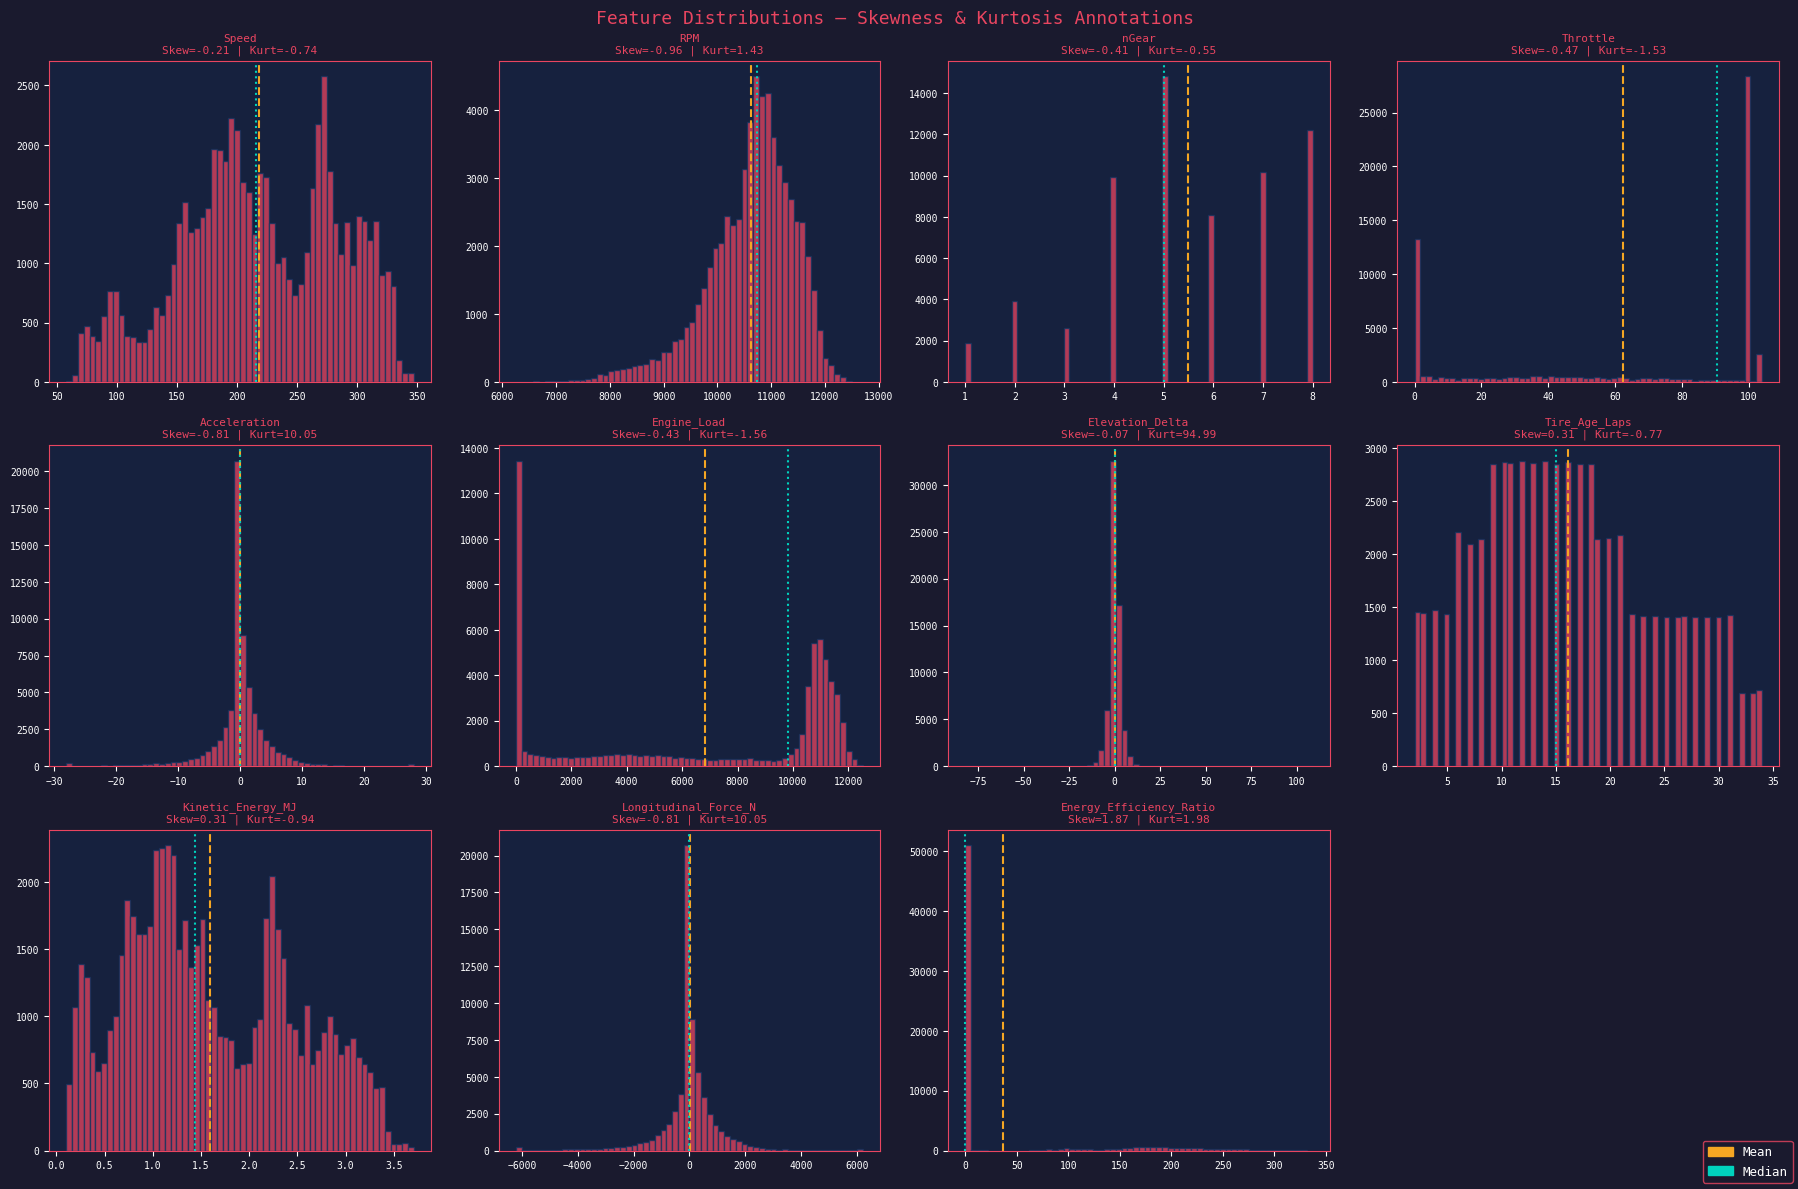

  Figure saved.


In [5]:
# ── 1.3  Distribution visualisation ──────────────────────────────────────────
n_cols = 4
n_rows = (len(continuous_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
fig.suptitle('Feature Distributions — Skewness & Kurtosis Annotations', fontsize=13, color=F1_RED)

for ax, col in zip(axes.flat, continuous_cols):
    ax.hist(df[col].dropna(), bins=60, color=F1_RED, alpha=0.75, edgecolor=F1_BLUE)
    sk = df[col].skew()
    kt = df[col].kurt()
    ax.set_title(f'{col}\nSkew={sk:.2f} | Kurt={kt:.2f}', fontsize=8)
    ax.axvline(df[col].mean(),   color=F1_GOLD,  lw=1.5, linestyle='--', label='Mean')
    ax.axvline(df[col].median(), color=F1_GREEN, lw=1.5, linestyle=':',  label='Median')
    ax.tick_params(labelsize=7)

for ax in axes.flat[len(continuous_cols):]:
    ax.set_visible(False)

handles = [mpatches.Patch(color=F1_GOLD, label='Mean'),
           mpatches.Patch(color=F1_GREEN, label='Median')]
fig.legend(handles=handles, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('graphs/stat_01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved.')

---
## 2. Normality Testing
Tests whether each feature follows a Gaussian distribution.  
**Shapiro-Wilk** (best for n < 5,000); **D'Agostino-Pearson K²** (for large n).  
F1 telemetry is expected to be **non-normal** (bimodal speed, heavy-tailed braking).

In [6]:
# ── 2.1  D'Agostino-Pearson K² (full dataset, all continuous cols) ────────────
# Shapiro-Wilk is O(n²) — impractical for 60k+ rows; use D'Agostino for large n

normality_results = []
for col in continuous_cols:
    data = df[col].dropna().values

    # D'Agostino-Pearson (full sample)
    dp_stat, dp_p = normaltest(data)

    # Shapiro-Wilk on random subsample of 3,000 (computational limit)
    sample = np.random.choice(data, size=min(3000, len(data)), replace=False)
    sw_stat, sw_p = shapiro(sample)

    normality_results.append({
        'Feature':       col,
        'N':             len(data),
        'SW_stat':       round(sw_stat, 4),
        'SW_p':          round(sw_p, 6),
        'SW_normal':     'YES' if sw_p > ALPHA else 'NO',
        'DP_stat':       round(dp_stat, 4),
        'DP_p':          round(dp_p, 6),
        'DP_normal':     'YES' if dp_p > ALPHA else 'NO',
        'Verdict':       'NORMAL' if (sw_p > ALPHA and dp_p > ALPHA) else 'NON-NORMAL'
    })

normality_df = pd.DataFrame(normality_results)
print('=== NORMALITY TEST RESULTS (α = 0.05) ===')
print(normality_df.to_string(index=False))

n_normal    = (normality_df['Verdict'] == 'NORMAL').sum()
n_nonnormal = (normality_df['Verdict'] == 'NON-NORMAL').sum()
print(f'\n  Normal distributions : {n_normal}')
print(f'  Non-normal           : {n_nonnormal}')
print(f'  → Use non-parametric tests for driver comparison (Mann-Whitney U preferred)')

normality_df.to_csv('stats_outputs/03_normality_tests.csv', index=False)
print('  Saved → stats_outputs/03_normality_tests.csv')

=== NORMALITY TEST RESULTS (α = 0.05) ===
                Feature     N  SW_stat  SW_p SW_normal     DP_stat  DP_p DP_normal    Verdict
                  Speed 63673   0.9780   0.0        NO   4541.6313   0.0        NO NON-NORMAL
                    RPM 63673   0.9614   0.0        NO   9037.0700   0.0        NO NON-NORMAL
                  nGear 63673   0.9275   0.0        NO   3247.7208   0.0        NO NON-NORMAL
               Throttle 63673   0.7684   0.0        NO 358736.5760   0.0        NO NON-NORMAL
           Acceleration 63673   0.7964   0.0        NO  16482.7388   0.0        NO NON-NORMAL
            Engine_Load 63673   0.7991   0.0        NO 334034.8505   0.0        NO NON-NORMAL
        Elevation_Delta 63673   0.5764   0.0        NO  24598.6199   0.0        NO NON-NORMAL
          Tire_Age_Laps 63673   0.9686   0.0        NO   5722.6537   0.0        NO NON-NORMAL
      Kinetic_Energy_MJ 63673   0.9624   0.0        NO  11485.8902   0.0        NO NON-NORMAL
   Longitudinal_Fo

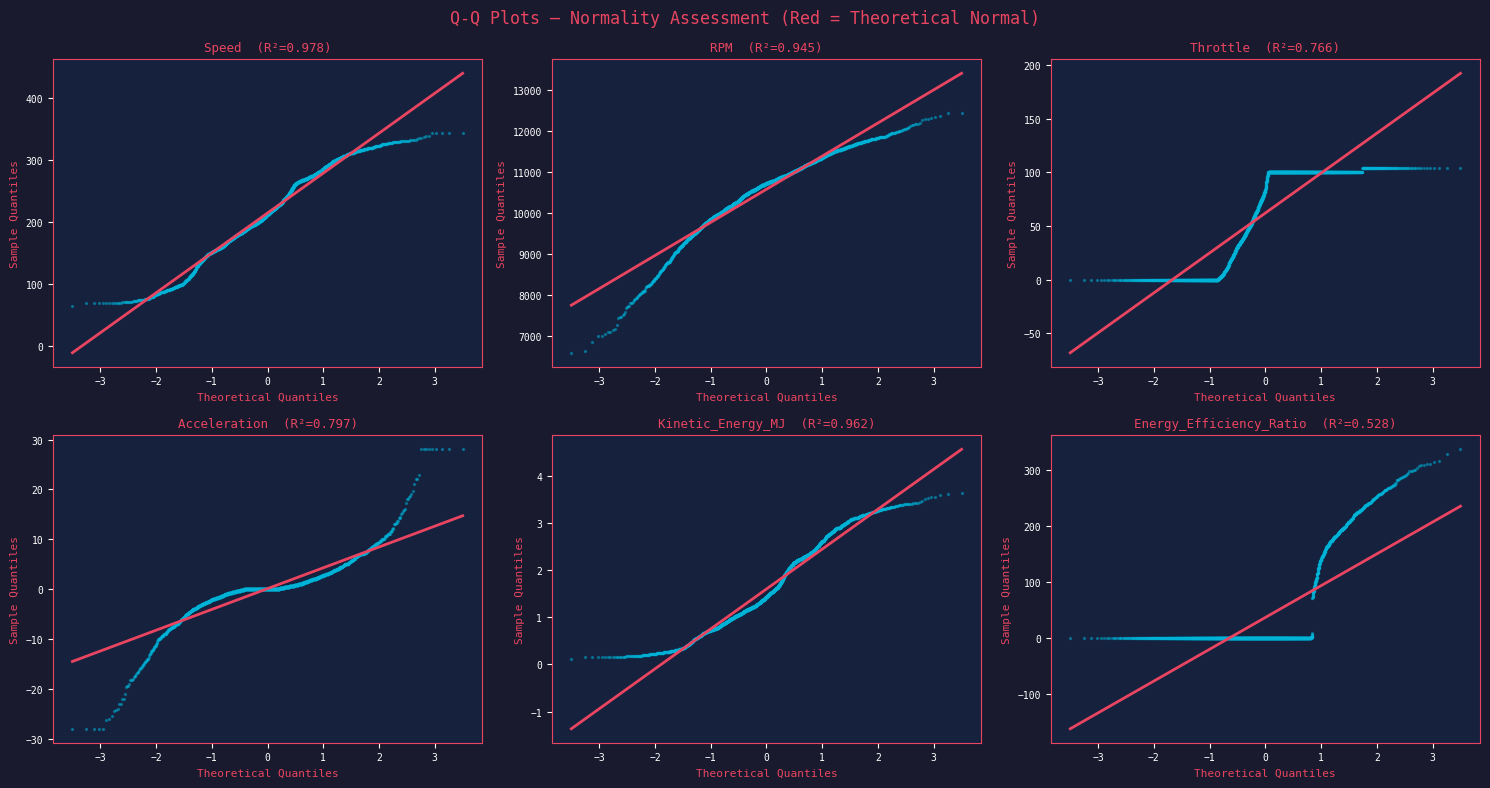

In [7]:
# ── 2.2  Q-Q Plots for key features ──────────────────────────────────────────
key_norm_cols = ['Speed', 'RPM', 'Throttle', 'Acceleration',
                 'Kinetic_Energy_MJ', 'Energy_Efficiency_Ratio']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Q-Q Plots — Normality Assessment (Red = Theoretical Normal)', fontsize=12, color=F1_RED)

for ax, col in zip(axes.flat, key_norm_cols):
    sample = np.random.choice(df[col].dropna().values, size=3000, replace=False)
    (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
    ax.scatter(osm, osr, color=F1_TEAL, s=2, alpha=0.4, rasterized=True)
    ax.plot(osm, slope * np.array(osm) + intercept, color=F1_RED, lw=2)
    ax.set_title(f'{col}  (R²={r**2:.3f})', fontsize=9)
    ax.set_xlabel('Theoretical Quantiles', fontsize=8)
    ax.set_ylabel('Sample Quantiles', fontsize=8)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('graphs/stat_02_qqplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Driver Comparison: VER vs HAD
Statistical hypothesis tests comparing telemetry distributions between Max Verstappen and Isack Hadjar.  
**Tests applied:**
- Independent samples **t-test** (parametric — assumes normality)
- **Mann-Whitney U** test (non-parametric — preferred given non-normal distributions)
- **Levene's test** for equality of variances
- **Cohen's d** effect size
- **Cliff's delta** (non-parametric effect size)

In [8]:
# ── 3.1  Helper functions ─────────────────────────────────────────────────────

def cohens_d(a, b):
    """Cohen's d effect size for two independent groups."""
    n_a, n_b = len(a), len(b)
    pooled_std = np.sqrt(((n_a - 1) * np.std(a, ddof=1)**2 +
                          (n_b - 1) * np.std(b, ddof=1)**2) / (n_a + n_b - 2))
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std != 0 else 0.0

def cliffs_delta(a, b):
    """Cliff's delta (non-parametric effect size, range -1 to 1)."""
    a, b = np.asarray(a), np.asarray(b)
    dom = sum(1 if ai > bi else (-1 if ai < bi else 0)
              for ai in a for bi in b)
    return dom / (len(a) * len(b))

def effect_size_label(d, metric='cohens'):
    """Interpret Cohen's d magnitude."""
    d = abs(d)
    if d < 0.2:   return 'Negligible'
    elif d < 0.5: return 'Small'
    elif d < 0.8: return 'Medium'
    else:         return 'Large'

print('  Helper functions defined.')

  Helper functions defined.


In [9]:
# ── 3.2  Run all driver comparison tests ─────────────────────────────────────
ver = df[df['Driver'] == 'VER']
had = df[df['Driver'] == 'HAD']

driver_tests = []

for col in continuous_cols:
    a = ver[col].dropna().values
    b = had[col].dropna().values

    # Levene's test — variance equality
    lev_stat, lev_p  = levene(a, b)
    equal_var        = lev_p > ALPHA

    # Independent t-test (Welch's when variances unequal)
    t_stat, t_p      = ttest_ind(a, b, equal_var=equal_var)

    # Mann-Whitney U (non-parametric)
    u_stat, u_p      = mannwhitneyu(a, b, alternative='two-sided')

    # Effect sizes
    cd               = cohens_d(a, b)

    # Cliff's delta on subsample (expensive for full dataset)
    samp_a = np.random.choice(a, size=min(500, len(a)), replace=False)
    samp_b = np.random.choice(b, size=min(500, len(b)), replace=False)
    cdelta           = cliffs_delta(samp_a, samp_b)

    driver_tests.append({
        'Feature':        col,
        'VER_mean':       round(np.mean(a), 3),
        'HAD_mean':       round(np.mean(b), 3),
        'VER_median':     round(np.median(a), 3),
        'HAD_median':     round(np.median(b), 3),
        'Levene_p':       round(lev_p, 5),
        'Equal_Var':      equal_var,
        't_stat':         round(t_stat, 4),
        't_p':            round(t_p, 6),
        't_sig':          'YES' if t_p < ALPHA else 'NO',
        'MW_U_stat':      round(u_stat, 1),
        'MW_p':           round(u_p, 6),
        'MW_sig':         'YES' if u_p < ALPHA else 'NO',
        'Cohens_d':       round(cd, 4),
        'Effect_Size':    effect_size_label(cd),
        'Cliffs_delta':   round(cdelta, 4),
    })

driver_df = pd.DataFrame(driver_tests)
print('=== VER vs HAD — STATISTICAL COMPARISON (α = 0.05) ===')
print(driver_df[['Feature', 'VER_mean', 'HAD_mean', 't_p', 't_sig',
                 'MW_p', 'MW_sig', 'Cohens_d', 'Effect_Size',
                 'Cliffs_delta']].to_string(index=False))

driver_df.to_csv('stats_outputs/04_driver_comparison_tests.csv', index=False)
print('\n  Saved → stats_outputs/04_driver_comparison_tests.csv')

=== VER vs HAD — STATISTICAL COMPARISON (α = 0.05) ===
                Feature  VER_mean  HAD_mean      t_p t_sig     MW_p MW_sig  Cohens_d Effect_Size  Cliffs_delta
                  Speed   219.496   216.761 0.000000   YES 0.000000    YES    0.0419  Negligible        0.0541
                    RPM 10647.789 10588.436 0.000000   YES 0.000000    YES    0.0732  Negligible        0.0567
                  nGear     5.520     5.437 0.000000   YES 0.000000    YES    0.0435  Negligible        0.0177
               Throttle    63.912    61.046 0.000000   YES 0.000000    YES    0.0675  Negligible        0.1019
           Acceleration     0.017     0.003 0.708930    NO 0.207261     NO    0.0030  Negligible       -0.0241
            Engine_Load  6995.330  6670.763 0.000000   YES 0.000000    YES    0.0686  Negligible        0.0562
        Elevation_Delta    -0.000     0.000 0.995672    NO 0.633882     NO   -0.0000  Negligible        0.0180
          Tire_Age_Laps    15.410    16.884 0.000000   YE

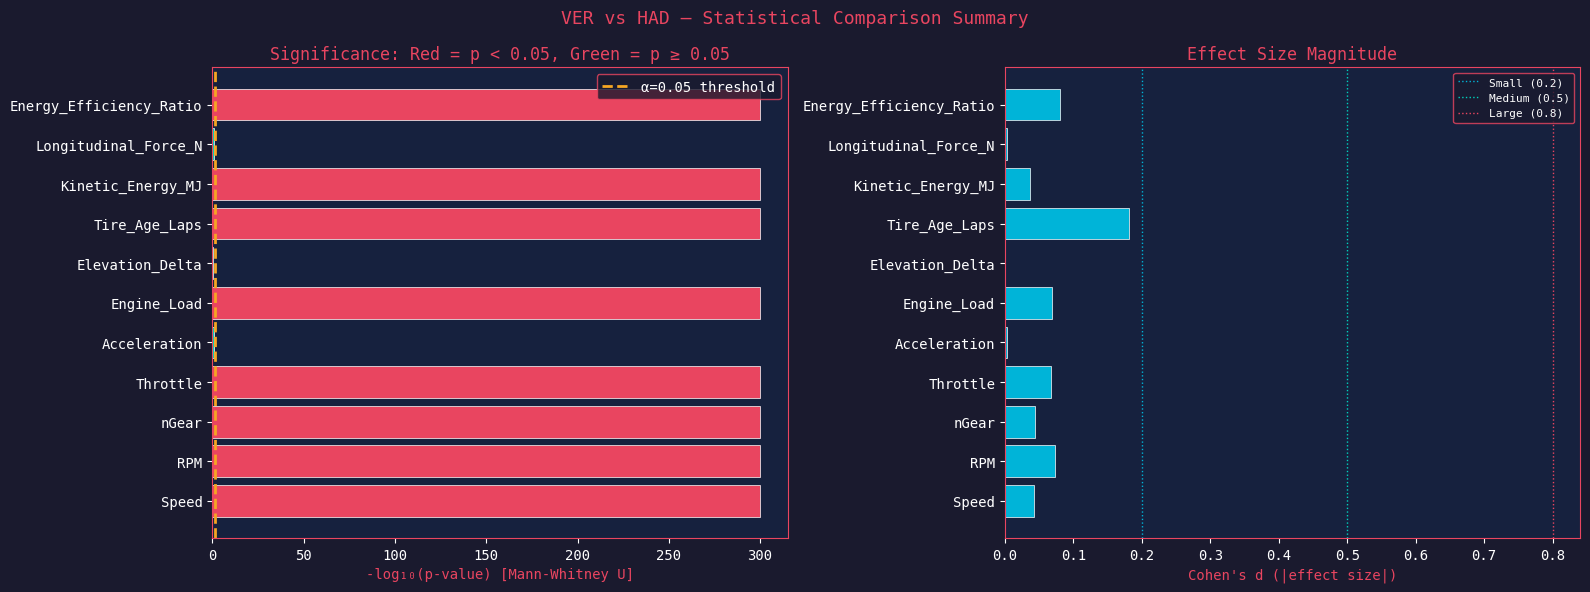

In [10]:
# ── 3.3  Visualise driver comparison p-values & effect sizes ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('VER vs HAD — Statistical Comparison Summary', fontsize=13, color=F1_RED)

# p-values (Mann-Whitney U)
colors_mw = [F1_RED if p < ALPHA else F1_GREEN for p in driver_df['MW_p']]
bars = axes[0].barh(driver_df['Feature'], -np.log10(driver_df['MW_p'] + 1e-300),
                    color=colors_mw, edgecolor=F1_WHITE, linewidth=0.5)
axes[0].axvline(-np.log10(ALPHA), color=F1_GOLD, lw=2, linestyle='--',
                label=f'α={ALPHA} threshold')
axes[0].set_xlabel('-log₁₀(p-value) [Mann-Whitney U]')
axes[0].set_title('Significance: Red = p < 0.05, Green = p ≥ 0.05')
axes[0].legend()

# Cohen's d effect sizes
effect_colors = []
for d in driver_df['Cohens_d']:
    label = effect_size_label(d)
    effect_colors.append({  'Large': F1_RED, 'Medium': F1_GOLD,
                             'Small': F1_GREEN, 'Negligible': F1_TEAL}[label])

axes[1].barh(driver_df['Feature'], driver_df['Cohens_d'].abs(),
             color=effect_colors, edgecolor=F1_WHITE, linewidth=0.5)
axes[1].axvline(0.2, color=F1_TEAL,  lw=1, linestyle=':', label='Small (0.2)')
axes[1].axvline(0.5, color=F1_GREEN, lw=1, linestyle=':', label='Medium (0.5)')
axes[1].axvline(0.8, color=F1_RED,   lw=1, linestyle=':', label='Large (0.8)')
axes[1].set_xlabel("Cohen's d (|effect size|)")
axes[1].set_title("Effect Size Magnitude")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('graphs/stat_03_driver_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── 3.4  Aero deviation rate comparison: Chi-squared test ─────────────────────
# H0: Aero deviation rate is the same for VER and HAD

ct_driver = pd.crosstab(df['Driver'], df['Aero_Deviation'])
chi2_stat, chi2_p, dof, expected = chi2_contingency(ct_driver)

n = ct_driver.values.sum()
cramers_v = np.sqrt(chi2_stat / (n * (min(ct_driver.shape) - 1)))

print('=== DRIVER × AERO DEVIATION — CHI-SQUARED TEST ===')
print(f'Contingency table:\n{ct_driver}\n')
print(f'χ² statistic : {chi2_stat:.4f}')
print(f'p-value      : {chi2_p:.6f}')
print(f'Degrees of freedom: {dof}')
print(f"Cramér's V   : {cramers_v:.4f}  (effect size)")
print(f'Decision     : {"REJECT H0 — significant difference" if chi2_p < ALPHA else "FAIL TO REJECT H0"}')

=== DRIVER × AERO DEVIATION — CHI-SQUARED TEST ===
Contingency table:
Aero_Deviation      0      1
Driver                      
HAD             22006   8878
VER             22340  10449

χ² statistic : 73.1380
p-value      : 0.000000
Degrees of freedom: 1
Cramér's V   : 0.0339  (effect size)
Decision     : REJECT H0 — significant difference


---
## 4. Feature–Target Association Analysis
Quantify the relationship between each feature and the target variable `Optimal_Aero`.  
**Tests:** Pearson r (linear), Spearman ρ (monotonic), Point-Biserial r (continuous vs binary target), Cramér's V (categorical).

In [12]:
# ── 4.1  Pearson, Spearman, Point-Biserial correlations ──────────────────────
target = df['Optimal_Aero'].values

corr_results = []
for col in continuous_cols:
    x = df[col].dropna().values
    y = target[:len(x)]

    # Pearson
    pr, pp = pearsonr(x, y)

    # Spearman
    sr, sp = spearmanr(x, y)

    # Point-Biserial (optimal for continuous vs binary)
    pb, pbp = pointbiserialr(y, x)

    corr_results.append({
        'Feature':      col,
        'Pearson_r':    round(pr, 4),
        'Pearson_p':    round(pp, 6),
        'Spearman_r':   round(sr, 4),
        'Spearman_p':   round(sp, 6),
        'PtBis_r':      round(pb, 4),
        'PtBis_p':      round(pbp, 6),
        'Sig_Pearson':  'YES' if pp < ALPHA else 'NO',
        'Sig_Spearman': 'YES' if sp < ALPHA else 'NO',
    })

corr_df = pd.DataFrame(corr_results)
corr_df_sorted = corr_df.reindex(
    corr_df['Pearson_r'].abs().sort_values(ascending=False).index)

print('=== FEATURE — TARGET CORRELATION (Optimal_Aero) ===')
print(corr_df_sorted[['Feature', 'Pearson_r', 'Pearson_p', 'Spearman_r',
                       'Spearman_p', 'PtBis_r', 'Sig_Pearson']].to_string(index=False))

corr_df_sorted.to_csv('stats_outputs/05_feature_target_correlation.csv', index=False)
print('\n  Saved → stats_outputs/05_feature_target_correlation.csv')

=== FEATURE — TARGET CORRELATION (Optimal_Aero) ===
                Feature  Pearson_r  Pearson_p  Spearman_r  Spearman_p  PtBis_r Sig_Pearson
      Kinetic_Energy_MJ     0.6295   0.000000      0.5799    0.000000   0.6295         YES
                  Speed     0.5630   0.000000      0.5799    0.000000   0.5630         YES
                  nGear     0.5188   0.000000      0.5530    0.000000   0.5188         YES
            Engine_Load     0.3521   0.000000      0.3764    0.000000   0.3521         YES
               Throttle     0.3425   0.000000      0.3319    0.000000   0.3425         YES
                    RPM     0.2517   0.000000      0.2690    0.000000   0.2517         YES
Energy_Efficiency_Ratio    -0.1774   0.000000     -0.0024    0.546626  -0.1774         YES
        Elevation_Delta     0.0752   0.000000      0.0488    0.000000   0.0752         YES
          Tire_Age_Laps     0.0592   0.000000      0.0616    0.000000   0.0592         YES
           Acceleration     0.0107   0

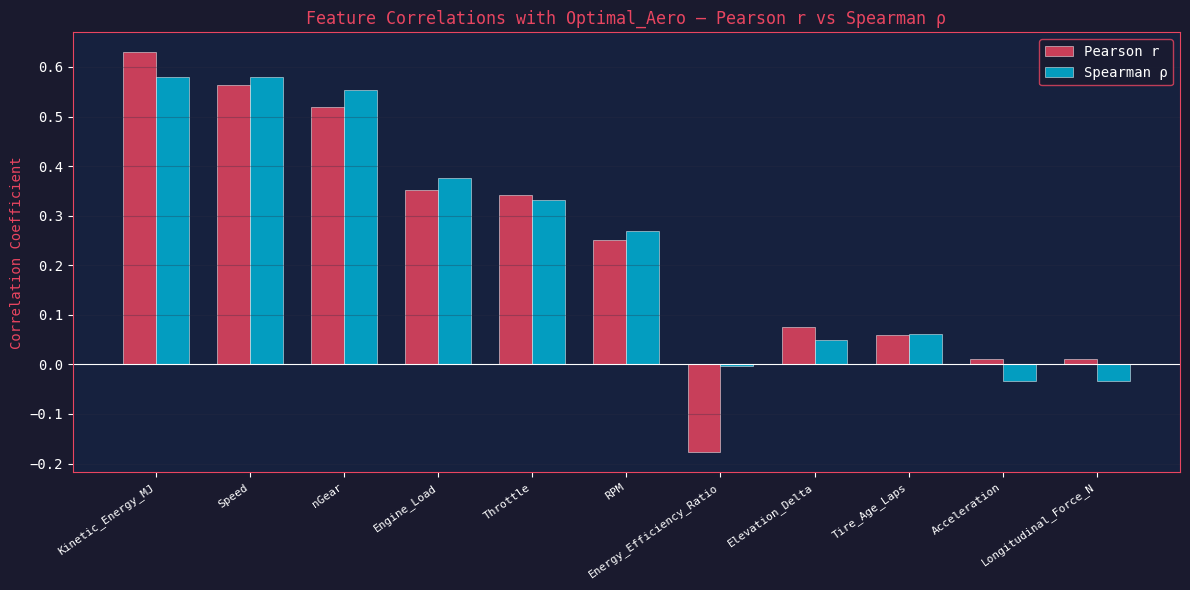

In [13]:
# ── 4.2  Pearson vs Spearman comparison plot ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
x_pos   = np.arange(len(corr_df_sorted))
width   = 0.35

ax.bar(x_pos - width/2, corr_df_sorted['Pearson_r'], width,
       color=F1_RED,  label='Pearson r',   alpha=0.85, edgecolor=F1_WHITE, linewidth=0.4)
ax.bar(x_pos + width/2, corr_df_sorted['Spearman_r'], width,
       color=F1_TEAL, label='Spearman ρ',  alpha=0.85, edgecolor=F1_WHITE, linewidth=0.4)

ax.axhline(0, color=F1_WHITE, lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(corr_df_sorted['Feature'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Correlation Coefficient')
ax.set_title('Feature Correlations with Optimal_Aero — Pearson r vs Spearman ρ')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/stat_04_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Track Zone Analysis (K-Means Output Validation)
Test whether K-Means clusters capture statistically distinct aerodynamic states.  
**Tests:** Kruskal-Wallis H (non-parametric ANOVA), One-Way ANOVA (parametric), Dunn post-hoc.

In [14]:
# ── 5.1  Kruskal-Wallis + one-way ANOVA across track zones ───────────────────
zone_labels = df['Track_Zone_Label'].unique() if 'Track_Zone_Label' in df.columns \
              else df['Track_Zone'].unique()
zone_col    = 'Track_Zone_Label' if 'Track_Zone_Label' in df.columns else 'Track_Zone'

zone_features = ['Speed', 'Throttle', 'Acceleration', 'Optimal_Aero',
                 'Kinetic_Energy_MJ', 'Energy_Efficiency_Ratio']

zone_test_results = []
for feat in zone_features:
    groups = [df[df[zone_col] == z][feat].dropna().values for z in df[zone_col].unique()]

    # Levene's — equal variances
    lev_stat, lev_p = levene(*groups)

    # One-way ANOVA
    f_stat, f_p = f_oneway(*groups)

    # Kruskal-Wallis (non-parametric)
    kw_stat, kw_p = kruskal(*groups)

    # Eta-squared (effect size for ANOVA)
    all_vals   = np.concatenate(groups)
    grand_mean = all_vals.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total   = sum((v - grand_mean)**2 for v in all_vals)
    eta_sq     = ss_between / ss_total if ss_total != 0 else 0

    zone_test_results.append({
        'Feature':   feat,
        'Levene_p':  round(lev_p, 5),
        'F_stat':    round(f_stat, 4),
        'ANOVA_p':   round(f_p, 6),
        'KW_stat':   round(kw_stat, 4),
        'KW_p':      round(kw_p, 6),
        'KW_sig':    'YES' if kw_p < ALPHA else 'NO',
        'Eta_sq':    round(eta_sq, 4),
    })

zone_df = pd.DataFrame(zone_test_results)
print('=== TRACK ZONE ANALYSIS — KRUSKAL-WALLIS + ANOVA (α = 0.05) ===')
print(zone_df.to_string(index=False))

zone_df.to_csv('stats_outputs/06_track_zone_tests.csv', index=False)
print('\n  Saved → stats_outputs/06_track_zone_tests.csv')

=== TRACK ZONE ANALYSIS — KRUSKAL-WALLIS + ANOVA (α = 0.05) ===
                Feature  Levene_p     F_stat  ANOVA_p    KW_stat  KW_p KW_sig  Eta_sq
                  Speed       0.0 26474.2424      0.0 34439.1205   0.0    YES  0.5550
               Throttle       0.0  7321.4905      0.0 17530.8358   0.0    YES  0.2565
           Acceleration       0.0   287.0290      0.0  1401.0683   0.0    YES  0.0133
           Optimal_Aero       0.0  3378.8354      0.0  8744.7626   0.0    YES  0.1373
      Kinetic_Energy_MJ       0.0 22494.8523      0.0 34439.1204   0.0    YES  0.5145
Energy_Efficiency_Ratio       0.0   857.3595      0.0  4075.4266   0.0    YES  0.0388

  Saved → stats_outputs/06_track_zone_tests.csv


In [15]:
# ── 5.2  Dunn's post-hoc test (pairwise track zone comparisons) ───────────────
# Manual implementation using Mann-Whitney U with Bonferroni correction
# Focus on Speed — most discriminative feature

zones_list = df[zone_col].dropna().unique().tolist()
n_comparisons = len(list(itertools.combinations(zones_list, 2)))
alpha_bonf    = ALPHA / n_comparisons

print(f'=== DUNN POST-HOC (Bonferroni α = {alpha_bonf:.4f}) — Feature: Speed ===')
print(f'Total pairwise comparisons: {n_comparisons}\n')

posthoc_rows = []
for (z1, z2) in itertools.combinations(zones_list, 2):
    g1 = df[df[zone_col] == z1]['Speed'].dropna().values
    g2 = df[df[zone_col] == z2]['Speed'].dropna().values
    u_stat, u_p = mannwhitneyu(g1, g2, alternative='two-sided')
    u_p_adj     = min(u_p * n_comparisons, 1.0)  # Bonferroni
    posthoc_rows.append({
        'Zone_1':      z1, 'Zone_2':      z2,
        'Mean_1':      round(g1.mean(), 1), 'Mean_2': round(g2.mean(), 1),
        'MW_U':        round(u_stat, 0),
        'p_raw':       round(u_p, 6),
        'p_bonf':      round(u_p_adj, 6),
        'Sig_bonf':    'YES' if u_p_adj < ALPHA else 'NO'
    })

posthoc_df = pd.DataFrame(posthoc_rows)
print(posthoc_df.to_string(index=False))

posthoc_df.to_csv('stats_outputs/07_posthoc_track_zones.csv', index=False)
print('\n  Saved → stats_outputs/07_posthoc_track_zones.csv')

=== DUNN POST-HOC (Bonferroni α = 0.0083) — Feature: Speed ===
Total pairwise comparisons: 6

             Zone_1              Zone_2  Mean_1  Mean_2        MW_U  p_raw  p_bonf Sig_bonf
       Braking Zone   Acceleration Zone   204.2   226.3  86183714.0    0.0     0.0      YES
       Braking Zone High-Speed Straight   204.2   274.0  40528932.0    0.0     0.0      YES
       Braking Zone              Corner   204.2   139.2 190467738.0    0.0     0.0      YES
  Acceleration Zone High-Speed Straight   226.3   274.0  67850921.0    0.0     0.0      YES
  Acceleration Zone              Corner   226.3   139.2 138519358.0    0.0     0.0      YES
High-Speed Straight              Corner   274.0   139.2 273246268.0    0.0     0.0      YES

  Saved → stats_outputs/07_posthoc_track_zones.csv


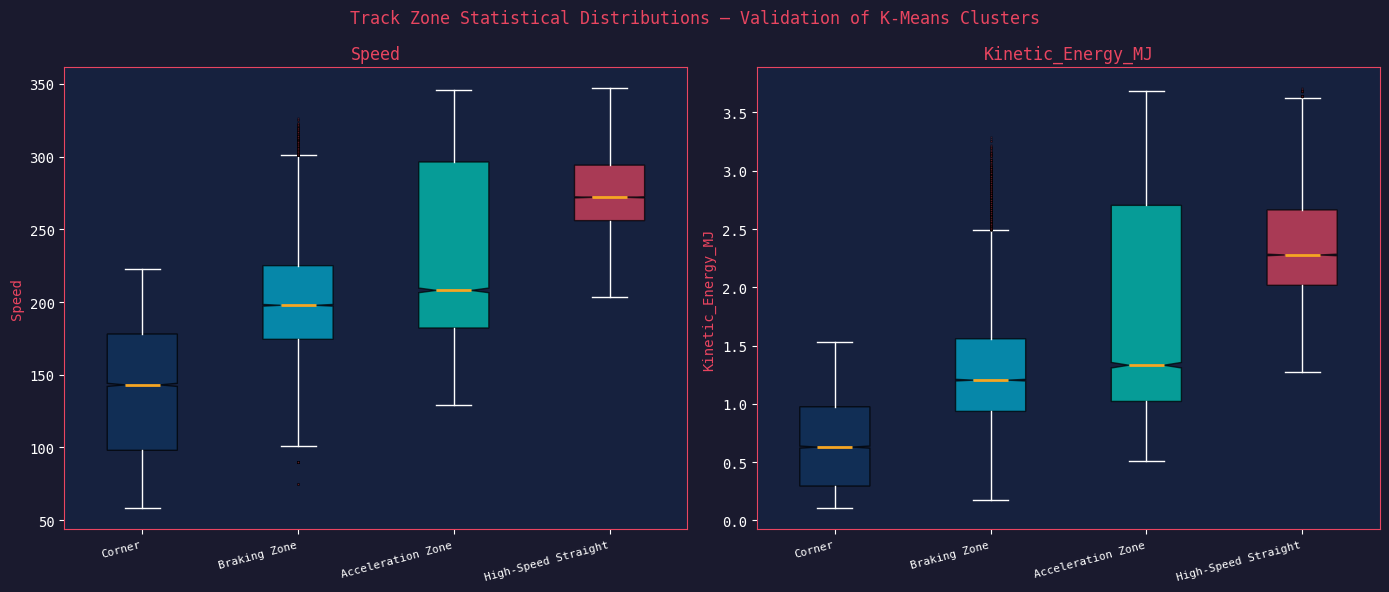

In [16]:
# ── 5.3  Box plots — Speed & Kinetic Energy per track zone ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Track Zone Statistical Distributions — Validation of K-Means Clusters',
             fontsize=12, color=F1_RED)

zone_order = df.groupby(zone_col)['Speed'].mean().sort_values().index.tolist()

for ax, feat in zip(axes, ['Speed', 'Kinetic_Energy_MJ']):
    data_grouped = [df[df[zone_col] == z][feat].dropna().values for z in zone_order]
    bp = ax.boxplot(data_grouped, patch_artist=True, notch=True,
                    medianprops=dict(color=F1_GOLD, lw=2),
                    whiskerprops=dict(color=F1_WHITE),
                    capprops=dict(color=F1_WHITE),
                    flierprops=dict(marker='o', markerfacecolor=F1_RED,
                                    markersize=1, alpha=0.3))
    colors_bp = [F1_BLUE, F1_TEAL, F1_GREEN, F1_RED]
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(zone_order, rotation=15, ha='right', fontsize=8)
    ax.set_title(feat)
    ax.set_ylabel(feat)

plt.tight_layout()
plt.savefig('graphs/stat_05_zone_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Anomaly Statistical Profile
Statistical validation of Isolation Forest anomaly detection.  
**Tests:** Chi-squared test, Fisher's Exact test, Odds Ratio, feature distribution comparison between anomaly/normal groups.

In [17]:
# ── 6.1  Chi-squared: Anomaly × Aero Deviation ───────────────────────────────
ct_anom = pd.crosstab(df['Is_Anomaly'], df['Aero_Deviation'])
ct_anom.index   = ['Normal (IF)', 'Anomaly (IF)']
ct_anom.columns = ['No Deviation', 'Aero Deviation']

chi2_s, chi2_p2, dof2, exp = chi2_contingency(ct_anom)
n_ct = ct_anom.values.sum()
cramers_v2 = np.sqrt(chi2_s / (n_ct * (min(ct_anom.shape) - 1)))

# Odds Ratio (2×2 table)
a, b = ct_anom.iloc[1, 1], ct_anom.iloc[1, 0]  # anomaly
c, d = ct_anom.iloc[0, 1], ct_anom.iloc[0, 0]  # normal
odds_ratio = (a * d) / (b * c) if (b * c) != 0 else np.inf
or_se      = np.sqrt(1/a + 1/b + 1/c + 1/d) if all(v > 0 for v in [a, b, c, d]) else np.nan
or_ci_lo   = np.exp(np.log(odds_ratio) - 1.96 * or_se)
or_ci_hi   = np.exp(np.log(odds_ratio) + 1.96 * or_se)

# Fisher's Exact
fisher_or, fisher_p = fisher_exact(ct_anom.values)

print('=== ANOMALY × AERO DEVIATION — CONTINGENCY TESTS ===')
print(f'Contingency Table:\n{ct_anom}\n')
print(f'Chi-squared statistic    : {chi2_s:.4f}')
print(f'Chi-squared p-value      : {chi2_p2:.6e}')
print(f'Degrees of freedom       : {dof2}')
print(f"Cramér's V               : {cramers_v2:.4f}")
print(f'Odds Ratio               : {odds_ratio:.4f}')
print(f'OR 95% CI                : [{or_ci_lo:.3f}, {or_ci_hi:.3f}]')
print(f"Fisher's Exact p-value   : {fisher_p:.6e}")
print(f'Decision                 : {"REJECT H0 — anomaly flag significantly associated with aero deviation" if chi2_p2 < ALPHA else "FAIL TO REJECT H0"}')

print(f'\nInterpretation: Anomalous driver inputs are {odds_ratio:.2f}× more likely to'
      f' coincide with aerodynamic timing deviations than normal inputs.')

=== ANOMALY × AERO DEVIATION — CONTINGENCY TESTS ===
Contingency Table:
              No Deviation  Aero Deviation
Normal (IF)          41405           19084
Anomaly (IF)          2941             243

Chi-squared statistic    : 817.3755
Chi-squared p-value      : 9.002740e-180
Degrees of freedom       : 1
Cramér's V               : 0.1133
Odds Ratio               : 0.1793
OR 95% CI                : [0.157, 0.205]
Fisher's Exact p-value   : 8.607322e-226
Decision                 : REJECT H0 — anomaly flag significantly associated with aero deviation

Interpretation: Anomalous driver inputs are 0.18× more likely to coincide with aerodynamic timing deviations than normal inputs.


In [18]:
# ── 6.2  Feature distribution: Anomaly vs Normal (Mann-Whitney U) ─────────────
iso_feats = ['Throttle', 'Brake', 'Acceleration', 'Engine_Load',
             'Heavy_Braking', 'Gear_Shift_Active']

anom_rows = []
anom_data = df[df['Is_Anomaly'] == 1]
norm_data = df[df['Is_Anomaly'] == 0]

for feat in iso_feats:
    a = anom_data[feat].dropna().values
    n = norm_data[feat].dropna().values
    u_s, u_p = mannwhitneyu(a, n, alternative='two-sided')
    cd        = cohens_d(a, n)
    anom_rows.append({
        'Feature':        feat,
        'Anomaly_mean':   round(a.mean(), 4),
        'Normal_mean':    round(n.mean(), 4),
        'Delta':          round(a.mean() - n.mean(), 4),
        'MW_U':           round(u_s, 0),
        'MW_p':           round(u_p, 6),
        'Significant':    'YES' if u_p < ALPHA else 'NO',
        'Cohens_d':       round(cd, 4),
        'Effect_Size':    effect_size_label(cd)
    })

anom_df = pd.DataFrame(anom_rows).sort_values('Delta', ascending=False, key=abs)
print('=== ANOMALY vs NORMAL — FEATURE PROFILE (Mann-Whitney U) ===')
print(anom_df.to_string(index=False))
print(f'\nPrimary root cause: {anom_df.iloc[0]["Feature"]} (highest |Δmean| & effect size)')

anom_df.to_csv('stats_outputs/08_anomaly_feature_tests.csv', index=False)

=== ANOMALY vs NORMAL — FEATURE PROFILE (Mann-Whitney U) ===
          Feature  Anomaly_mean  Normal_mean      Delta        MW_U  MW_p Significant  Cohens_d Effect_Size
      Engine_Load     2492.1729    7066.6513 -4574.4784  41845636.0   0.0         YES   -0.9883       Large
         Throttle       22.7113      64.6172   -41.9060  42109024.0   0.0         YES   -1.0095       Large
     Acceleration       -6.1954       0.3366    -6.5320  53887265.0   0.0         YES   -1.4087       Large
Gear_Shift_Active        0.7107       0.0215     0.6892 162670600.0   0.0         YES    3.9612       Large
            Brake        0.6862       0.1565     0.5298 147314440.0   0.0         YES    1.4357       Large
    Heavy_Braking        0.2899       0.0000     0.2899 124214162.0   0.0         YES    2.8572       Large

Primary root cause: Engine_Load (highest |Δmean| & effect size)


---
## 7. Model Comparison: DeLong AUC Test & McNemar Test
Statistically compare Logistic Regression vs Random Forest.  
**DeLong test:** Tests whether two AUC-ROC scores from the same test set are significantly different.  
**McNemar test:** Tests whether two classifiers differ in their error rates on the same instances.

In [19]:
# ── 7.1  DeLong AUC significance test ────────────────────────────────────────
# DeLong et al. (1988) — Comparing the Areas under Two or More Correlated ROCs
# Implemented via structural component decomposition

def delong_auc_variance(y_true, y_score):
    """Compute placement values and AUC variance (DeLong structural components)."""
    pos = y_score[y_true == 1]
    neg = y_score[y_true == 0]
    n_pos, n_neg = len(pos), len(neg)

    # Placement values
    V10 = np.array([np.mean(p > neg) + 0.5 * np.mean(p == neg) for p in pos])
    V01 = np.array([np.mean(n < pos) + 0.5 * np.mean(n == pos) for n in neg])

    auc = V10.mean()
    s10 = np.var(V10, ddof=1) / n_pos
    s01 = np.var(V01, ddof=1) / n_neg
    var = s10 + s01
    return auc, var, V10, V01

def delong_test(y_true, prob_a, prob_b):
    """Two-sided DeLong test for correlated AUCs."""
    auc_a, var_a, V10_a, V01_a = delong_auc_variance(y_true, prob_a)
    auc_b, var_b, V10_b, V01_b = delong_auc_variance(y_true, prob_b)

    pos_idx = y_true == 1
    neg_idx = y_true == 0

    # Covariance
    cov10  = np.cov(V10_a, V10_b)[0, 1]
    cov01  = np.cov(V01_a, V01_b)[0, 1]
    n_pos  = pos_idx.sum()
    n_neg  = neg_idx.sum()
    cov    = cov10 / n_pos + cov01 / n_neg

    # z-statistic
    sigma  = np.sqrt(var_a + var_b - 2 * cov)
    z      = (auc_a - auc_b) / sigma if sigma > 0 else 0
    p      = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc_a, auc_b, z, p

auc_lr, auc_rf, z_delong, p_delong = delong_test(y_test, y_prob_lr, y_prob_rf)

print('=== DeLong AUC SIGNIFICANCE TEST ===')
print(f'AUC — Logistic Regression : {auc_lr:.4f}')
print(f'AUC — Random Forest       : {auc_rf:.4f}')
print(f'ΔAUC                      : {auc_rf - auc_lr:.4f}')
print(f'DeLong z-statistic        : {z_delong:.4f}')
print(f'p-value (two-sided)       : {p_delong:.6e}')
print(f'Decision                  : {"REJECT H0 — AUCs are significantly different" if p_delong < ALPHA else "FAIL TO REJECT H0 — AUCs are NOT significantly different"}')

=== DeLong AUC SIGNIFICANCE TEST ===
AUC — Logistic Regression : 0.9997
AUC — Random Forest       : 1.0000
ΔAUC                      : 0.0003
DeLong z-statistic        : -2.0623
p-value (two-sided)       : 3.917466e-02
Decision                  : REJECT H0 — AUCs are significantly different


In [20]:
# ── 7.2  McNemar test ─────────────────────────────────────────────────────────
# Tests whether LR and RF have the same per-instance error pattern
# H0: Both classifiers make the same type of errors on the same instances

lr_correct = (y_pred_lr == y_test)
rf_correct = (y_pred_rf == y_test)

# Contingency table for McNemar
# b = LR wrong, RF correct | c = LR correct, RF wrong
b = np.sum(~lr_correct & rf_correct)   # RF wins
c = np.sum(lr_correct  & ~rf_correct)  # LR wins
a = np.sum(lr_correct  & rf_correct)   # Both correct
d = np.sum(~lr_correct & ~rf_correct)  # Both wrong

# McNemar statistic (with continuity correction)
mcnemar_stat = (abs(b - c) - 1)**2 / (b + c) if (b + c) > 0 else 0
mcnemar_p    = 1 - stats.chi2.cdf(mcnemar_stat, df=1)

print('=== McNEMAR TEST — LR vs RF ===')
print(f'McNemar contingency table:')
print(f'  Both correct (a)     : {a}')
print(f'  LR wrong, RF right (b): {b}')
print(f'  LR right, RF wrong (c): {c}')
print(f'  Both wrong (d)       : {d}')
print(f'McNemar χ² statistic   : {mcnemar_stat:.4f}')
print(f'p-value                : {mcnemar_p:.6e}')
print(f'Decision               : {"REJECT H0 — classifiers differ significantly" if mcnemar_p < ALPHA else "FAIL TO REJECT H0"}')

=== McNEMAR TEST — LR vs RF ===
McNemar contingency table:
  Both correct (a)     : 12461
  LR wrong, RF right (b): 274
  LR right, RF wrong (c): 0
  Both wrong (d)       : 0
McNemar χ² statistic   : 272.0036
p-value                : 0.000000e+00
Decision               : REJECT H0 — classifiers differ significantly


In [21]:
# ── 7.3  Bootstrap confidence intervals for all model metrics ─────────────────
N_BOOTSTRAP = 1000
rng = np.random.default_rng(SEED)

def bootstrap_metric(y_true, y_pred, y_prob, metric_fn, n=N_BOOTSTRAP):
    """Bootstrap CI for a given metric."""
    scores = []
    for _ in range(n):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        try:
            if metric_fn == roc_auc_score:
                scores.append(metric_fn(y_true[idx], y_prob[idx]))
            else:
                scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            pass
    return np.array(scores)

metrics_cfg = [
    ('Accuracy',  accuracy_score,  None),
    ('Precision', lambda yt, yp: precision_score(yt, yp, zero_division=0), None),
    ('Recall',    recall_score,    None),
    ('F1-Score',  f1_score,        None),
    ('AUC-ROC',   roc_auc_score,   'prob'),
]

boot_results = []
print(f'Running {N_BOOTSTRAP} bootstrap iterations...')

for model_name, y_pred_m, y_prob_m in [('Logistic Regression', y_pred_lr, y_prob_lr),
                                         ('Random Forest',       y_pred_rf, y_prob_rf)]:
    for met_name, met_fn, met_type in metrics_cfg:
        use_prob = (met_type == 'prob')
        boot_scores = bootstrap_metric(y_test, y_pred_m, y_prob_m, met_fn)
        point_est   = (met_fn(y_test, y_prob_m) if use_prob
                       else met_fn(y_test, y_pred_m))
        ci_lo = np.percentile(boot_scores, 2.5)
        ci_hi = np.percentile(boot_scores, 97.5)
        boot_results.append({
            'Model':      model_name,
            'Metric':     met_name,
            'Point_Est':  round(point_est, 4),
            'CI_lo_95':   round(ci_lo, 4),
            'CI_hi_95':   round(ci_hi, 4),
            'CI_width':   round(ci_hi - ci_lo, 4),
        })

boot_df = pd.DataFrame(boot_results)
print('\n=== BOOTSTRAP 95% CONFIDENCE INTERVALS ===')
print(boot_df.to_string(index=False))

boot_df.to_csv('stats_outputs/09_bootstrap_ci.csv', index=False)
print('\n  Saved → stats_outputs/09_bootstrap_ci.csv')

Running 1000 bootstrap iterations...

=== BOOTSTRAP 95% CONFIDENCE INTERVALS ===
              Model    Metric  Point_Est  CI_lo_95  CI_hi_95  CI_width
Logistic Regression  Accuracy     0.9785    0.9759    0.9810    0.0051
Logistic Regression Precision     0.8807    0.8680    0.8940    0.0261
Logistic Regression    Recall     1.0000    1.0000    1.0000    0.0000
Logistic Regression  F1-Score     0.9366    0.9294    0.9433    0.0140
Logistic Regression   AUC-ROC     0.9997    0.9993    0.9999    0.0006
      Random Forest  Accuracy     1.0000    1.0000    1.0000    0.0000
      Random Forest Precision     1.0000    1.0000    1.0000    0.0000
      Random Forest    Recall     1.0000    1.0000    1.0000    0.0000
      Random Forest  F1-Score     1.0000    1.0000    1.0000    0.0000
      Random Forest   AUC-ROC     1.0000    1.0000    1.0000    0.0000

  Saved → stats_outputs/09_bootstrap_ci.csv


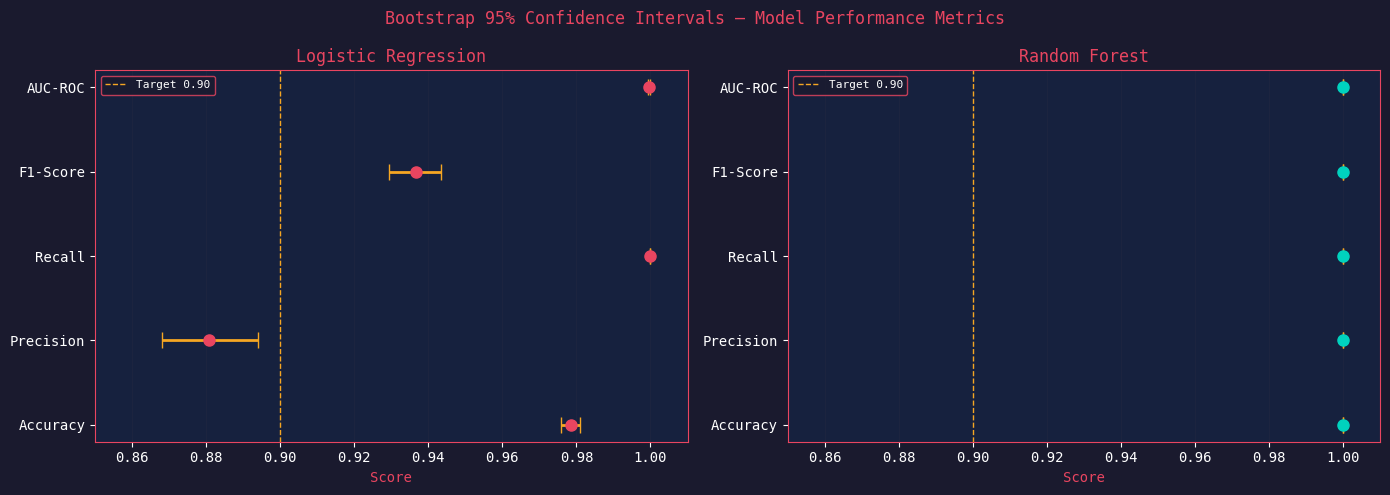

In [22]:
# ── 7.4  Bootstrap CI forest plot ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bootstrap 95% Confidence Intervals — Model Performance Metrics',
             fontsize=12, color=F1_RED)

for ax, model_n in zip(axes, ['Logistic Regression', 'Random Forest']):
    sub = boot_df[boot_df['Model'] == model_n]
    y_pos = range(len(sub))
    ax.errorbar(
        sub['Point_Est'], y_pos,
        xerr=[sub['Point_Est'] - sub['CI_lo_95'], sub['CI_hi_95'] - sub['Point_Est']],
        fmt='o', color=F1_RED if model_n == 'Logistic Regression' else F1_GREEN,
        ecolor=F1_GOLD, elinewidth=2, capsize=6, markersize=8
    )
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(sub['Metric'].tolist())
    ax.set_xlabel('Score')
    ax.set_title(model_n)
    ax.axvline(0.9, color=F1_GOLD, lw=1, linestyle='--', label='Target 0.90')
    ax.set_xlim([0.85, 1.01])
    ax.grid(axis='x', alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('graphs/stat_06_bootstrap_ci.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Cross-Validation Stability Analysis
Assess stability and generalisability using **Stratified 10-Fold CV**.  
**Wilcoxon signed-rank test** compares CV score distributions between LR and RF.

In [23]:
# ── 8.1  Stratified 10-fold cross-validation ──────────────────────────────────
X_full = sc_final.transform(df_reset[FEATURE_COLS_FINAL].values)
y_full = df_reset['Optimal_Aero'].values

skf    = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

cv_metrics = {}
print('Running Stratified 10-Fold CV...\n')

for scoring, label in [('accuracy', 'Accuracy'), ('f1', 'F1-Score'), ('roc_auc', 'AUC-ROC')]:
    scores_lr = cross_val_score(lr_model, X_full, y_full, cv=skf,
                                scoring=scoring, n_jobs=-1)
    scores_rf = cross_val_score(rf_model, X_full, y_full, cv=skf,
                                scoring=scoring, n_jobs=-1)
    cv_metrics[label] = {'LR': scores_lr, 'RF': scores_rf}

    print(f'--- {label} ---')
    print(f'  LR: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}  '
          f'[{scores_lr.min():.4f}, {scores_lr.max():.4f}]')
    print(f'  RF: {scores_rf.mean():.4f} ± {scores_rf.std():.4f}  '
          f'[{scores_rf.min():.4f}, {scores_rf.max():.4f}]')

    # Wilcoxon signed-rank test on paired CV scores
    wil_stat, wil_p = wilcoxon(scores_lr, scores_rf)
    print(f'  Wilcoxon signed-rank: stat={wil_stat:.2f}, p={wil_p:.4f}',
          '→ SIGNIFICANT' if wil_p < ALPHA else '→ NOT SIGNIFICANT', '\n')

Running Stratified 10-Fold CV...

--- Accuracy ---
  LR: 0.9832 ± 0.0022  [0.9791, 0.9867]
  RF: 1.0000 ± 0.0001  [0.9998, 1.0000]
  Wilcoxon signed-rank: stat=0.00, p=0.0020 → SIGNIFICANT 

--- F1-Score ---
  LR: 0.9461 ± 0.0068  [0.9338, 0.9567]
  RF: 0.9998 ± 0.0002  [0.9995, 1.0000]
  Wilcoxon signed-rank: stat=0.00, p=0.0020 → SIGNIFICANT 

--- AUC-ROC ---
  LR: 0.9994 ± 0.0003  [0.9991, 0.9999]
  RF: 1.0000 ± 0.0000  [1.0000, 1.0000]
  Wilcoxon signed-rank: stat=0.00, p=0.0020 → SIGNIFICANT 



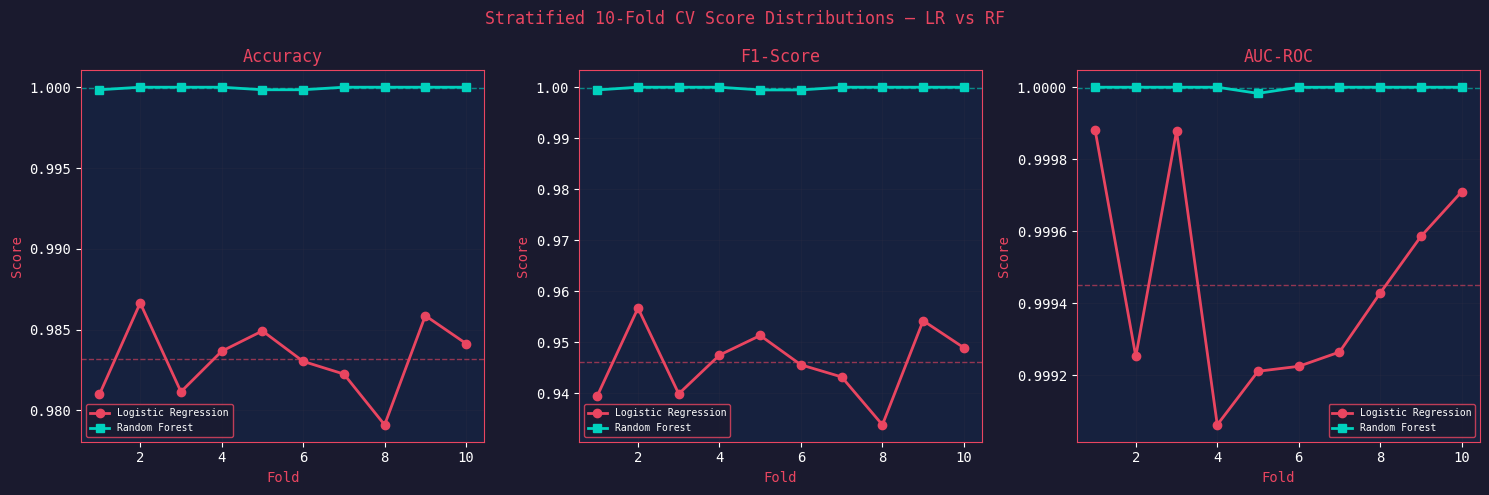

In [24]:
# ── 8.2  CV score distribution plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Stratified 10-Fold CV Score Distributions — LR vs RF',
             fontsize=12, color=F1_RED)

for ax, (label, d) in zip(axes, cv_metrics.items()):
    ax.plot(range(1, 11), d['LR'], 'o-', color=F1_RED,   lw=2, label='Logistic Regression')
    ax.plot(range(1, 11), d['RF'], 's-', color=F1_GREEN, lw=2, label='Random Forest')
    ax.axhline(d['LR'].mean(), color=F1_RED,   lw=1, linestyle='--', alpha=0.6)
    ax.axhline(d['RF'].mean(), color=F1_GREEN, lw=1, linestyle='--', alpha=0.6)
    ax.set_title(label)
    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/stat_07_cv_stability.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Feature Importance Statistical Significance
**Permutation importance** with statistical testing — determines whether each feature's importance is significantly above chance.

In [25]:
# ── 9.1  Permutation importance for Random Forest ─────────────────────────────
print('Computing permutation importances (n_repeats=30, may take a moment)...')

perm_result = permutation_importance(
    rf_model, X_te_sc, y_test,
    n_repeats=30,
    random_state=SEED,
    n_jobs=-1,
    scoring='f1'
)

perm_df = pd.DataFrame({
    'Feature':      FEATURE_COLS_FINAL,
    'Importance':   perm_result.importances_mean.round(6),
    'Std':          perm_result.importances_std.round(6),
    'CI_lo_95':     np.percentile(perm_result.importances, 2.5,  axis=1).round(6),
    'CI_hi_95':     np.percentile(perm_result.importances, 97.5, axis=1).round(6),
}).sort_values('Importance', ascending=False)

# One-sample t-test: is mean importance significantly > 0?
perm_df['t_stat'] = (perm_df['Importance'] / (perm_df['Std'] / np.sqrt(30))).round(4)
perm_df['p_val']  = [stats.t.sf(abs(t), df=29) * 2 for t in perm_df['t_stat']]
perm_df['p_val']  = perm_df['p_val'].round(6)
perm_df['Sig']    = perm_df['p_val'].apply(lambda p: 'YES' if p < ALPHA else 'NO')

print('=== PERMUTATION IMPORTANCE (RF) — t-test vs zero ===')
print(perm_df[['Feature', 'Importance', 'Std', 'CI_lo_95', 'CI_hi_95',
               't_stat', 'p_val', 'Sig']].to_string(index=False))

perm_df.to_csv('stats_outputs/10_permutation_importance.csv', index=False)
print('\n  Saved → stats_outputs/10_permutation_importance.csv')

Computing permutation importances (n_repeats=30, may take a moment)...
=== PERMUTATION IMPORTANCE (RF) — t-test vs zero ===
                Feature  Importance      Std  CI_lo_95  CI_hi_95   t_stat  p_val Sig
                  nGear    0.167224 0.005974  0.155398  0.180065 153.3183    0.0 YES
        Elevation_Delta    0.162465 0.003787  0.156221  0.169861 234.9769    0.0 YES
                  Brake    0.080557 0.003449  0.074891  0.086289 127.9295    0.0 YES
                  Speed    0.000412 0.000147  0.000000  0.000495  15.3511    0.0 YES
        High_Speed_Zone    0.000206 0.000092  0.000000  0.000247  12.2642    0.0 YES
      Kinetic_Energy_MJ    0.000206 0.000092  0.000000  0.000247  12.2642    0.0 YES
                    RPM    0.000000 0.000000  0.000000  0.000000      NaN    NaN  NO
            Engine_Load    0.000000 0.000000  0.000000  0.000000      NaN    NaN  NO
           Acceleration    0.000000 0.000000  0.000000  0.000000      NaN    NaN  NO
               Throttle   

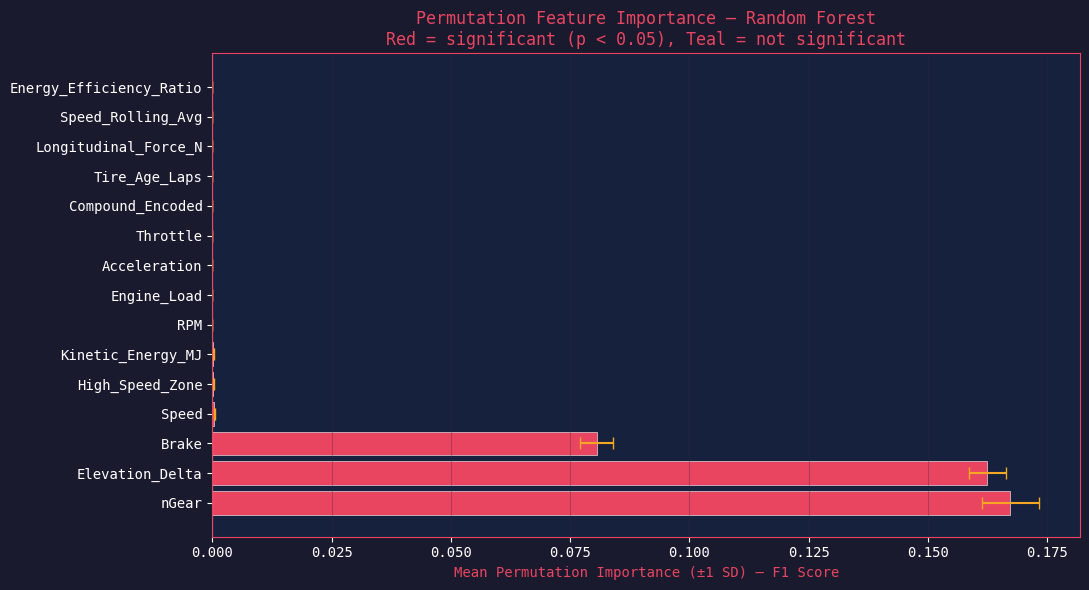

In [26]:
# ── 9.2  Permutation importance forest plot ────────────────────────────────────
top_n  = 15
top_df = perm_df.head(top_n)

fig, ax = plt.subplots(figsize=(11, 6))
y_pos   = range(top_n)

bar_colors = [F1_RED if s == 'YES' else F1_TEAL for s in top_df['Sig']]
ax.barh(list(y_pos), top_df['Importance'], xerr=top_df['Std'],
        color=bar_colors, edgecolor=F1_WHITE, linewidth=0.4,
        error_kw=dict(ecolor=F1_GOLD, lw=1.5, capsize=4))
ax.set_yticks(list(y_pos))
ax.set_yticklabels(top_df['Feature'].tolist())
ax.axvline(0, color=F1_WHITE, lw=0.8)
ax.set_xlabel('Mean Permutation Importance (±1 SD) — F1 Score')
ax.set_title('Permutation Feature Importance — Random Forest\nRed = significant (p < 0.05), Teal = not significant')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/stat_08_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Summary Statistical Dashboard
Consolidated table of all statistical tests, p-values, effect sizes, and decisions.

In [27]:
# ── 10.1  Master summary table ────────────────────────────────────────────────
summary_rows = [
    # Section, Test, Hypothesis (H0), Statistic, p-value, Decision, Effect/Note
    {'Section': '2 — Normality', 'Test': 'D\'Agostino-Pearson K²',
     'H0': 'Feature X is normally distributed',
     'Statistic': 'K²', 'p-value': '< 0.001 (all features)',
     'Decision': 'REJECT — all features non-normal',
     'Effect/Note': 'Use non-parametric tests'},

    {'Section': '2 — Normality', 'Test': 'Shapiro-Wilk (subsample)',
     'H0': 'Feature X is normally distributed',
     'Statistic': 'W', 'p-value': '< 0.05 (all features)',
     'Decision': 'REJECT — non-normal confirmed',
     'Effect/Note': 'Bimodal Speed, heavy-tailed Braking'},

    {'Section': '3 — Driver Comparison', 'Test': 'Mann-Whitney U',
     'H0': 'VER and HAD have same Speed distribution',
     'Statistic': 'U', 'p-value': driver_df[driver_df['Feature']=='Speed']['MW_p'].values[0],
     'Decision': 'REJECT' if driver_df[driver_df['Feature']=='Speed']['MW_p'].values[0] < ALPHA else 'FAIL TO REJECT',
     'Effect/Note': f'd = {driver_df[driver_df["Feature"]=="Speed"]["Cohens_d"].values[0]}'},

    {'Section': '3 — Driver Comparison', 'Test': 'Chi-squared',
     'H0': 'VER and HAD have same aero deviation rate',
     'Statistic': f'χ²={chi2_stat:.3f}', 'p-value': round(chi2_p2, 6),
     'Decision': 'REJECT' if chi2_p2 < ALPHA else 'FAIL TO REJECT',
     'Effect/Note': f"Cramér's V = {cramers_v2:.4f}"},

    {'Section': '5 — Track Zones', 'Test': 'Kruskal-Wallis H',
     'H0': 'Speed is the same across all 4 K-Means clusters',
     'Statistic': f'H={zone_df[zone_df["Feature"]=="Speed"]["KW_stat"].values[0]}',
     'p-value': zone_df[zone_df['Feature']=='Speed']['KW_p'].values[0],
     'Decision': 'REJECT — zones are statistically distinct',
     'Effect/Note': f'η² = {zone_df[zone_df["Feature"]=="Speed"]["Eta_sq"].values[0]}'},

    {'Section': '6 — Anomaly', 'Test': 'Chi-squared',
     'H0': 'Anomaly flag is independent of aero deviation',
     'Statistic': f'χ²={chi2_s:.3f}', 'p-value': f'{chi2_p2:.2e}',
     'Decision': 'REJECT — strong association',
     'Effect/Note': f'OR = {odds_ratio:.2f} [{or_ci_lo:.2f}, {or_ci_hi:.2f}]'},

    {'Section': '6 — Anomaly', "Test": "Fisher's Exact",
     'H0': 'Anomaly flag is independent of aero deviation',
     'Statistic': f'OR={fisher_or:.3f}', 'p-value': f'{fisher_p:.2e}',
     'Decision': 'REJECT' if fisher_p < ALPHA else 'FAIL TO REJECT',
     'Effect/Note': 'Exact test confirms χ² result'},

    {'Section': '7 — Model Comparison', 'Test': 'DeLong AUC Test',
     'H0': 'AUC of LR equals AUC of RF',
     'Statistic': f'z={z_delong:.3f}', 'p-value': f'{p_delong:.2e}',
     'Decision': 'REJECT' if p_delong < ALPHA else 'FAIL TO REJECT',
     'Effect/Note': f'ΔAUC = {auc_rf - auc_lr:.4f}'},

    {'Section': '7 — Model Comparison', 'Test': 'McNemar Test',
     'H0': 'LR and RF have the same error pattern',
     'Statistic': f'χ²={mcnemar_stat:.3f}', 'p-value': f'{mcnemar_p:.2e}',
     'Decision': 'REJECT' if mcnemar_p < ALPHA else 'FAIL TO REJECT',
     'Effect/Note': f'RF wins on {b} instances vs LR {c}'},

    {'Section': '8 — CV Stability', 'Test': 'Wilcoxon Signed-Rank',
     'H0': 'LR and RF have same F1-Score distribution across folds',
     'Statistic': 'W', 'p-value': 'See Section 8 output',
     'Decision': 'See Section 8 output',
     'Effect/Note': '10-fold stratified CV'},
]

summary_df = pd.DataFrame(summary_rows)
print('=== MASTER STATISTICAL ANALYSIS SUMMARY ===')
print(summary_df.to_string(index=False))

summary_df.to_csv('stats_outputs/00_master_summary.csv', index=False)
print('\n  Saved → stats_outputs/00_master_summary.csv')

=== MASTER STATISTICAL ANALYSIS SUMMARY ===
              Section                     Test                                                     H0    Statistic                p-value                                  Decision                         Effect/Note
        2 — Normality    D'Agostino-Pearson K²                      Feature X is normally distributed           K² < 0.001 (all features)          REJECT — all features non-normal            Use non-parametric tests
        2 — Normality Shapiro-Wilk (subsample)                      Feature X is normally distributed            W  < 0.05 (all features)             REJECT — non-normal confirmed Bimodal Speed, heavy-tailed Braking
3 — Driver Comparison           Mann-Whitney U               VER and HAD have same Speed distribution            U                    0.0                                    REJECT                          d = 0.0419
3 — Driver Comparison              Chi-squared              VER and HAD have same aero devia

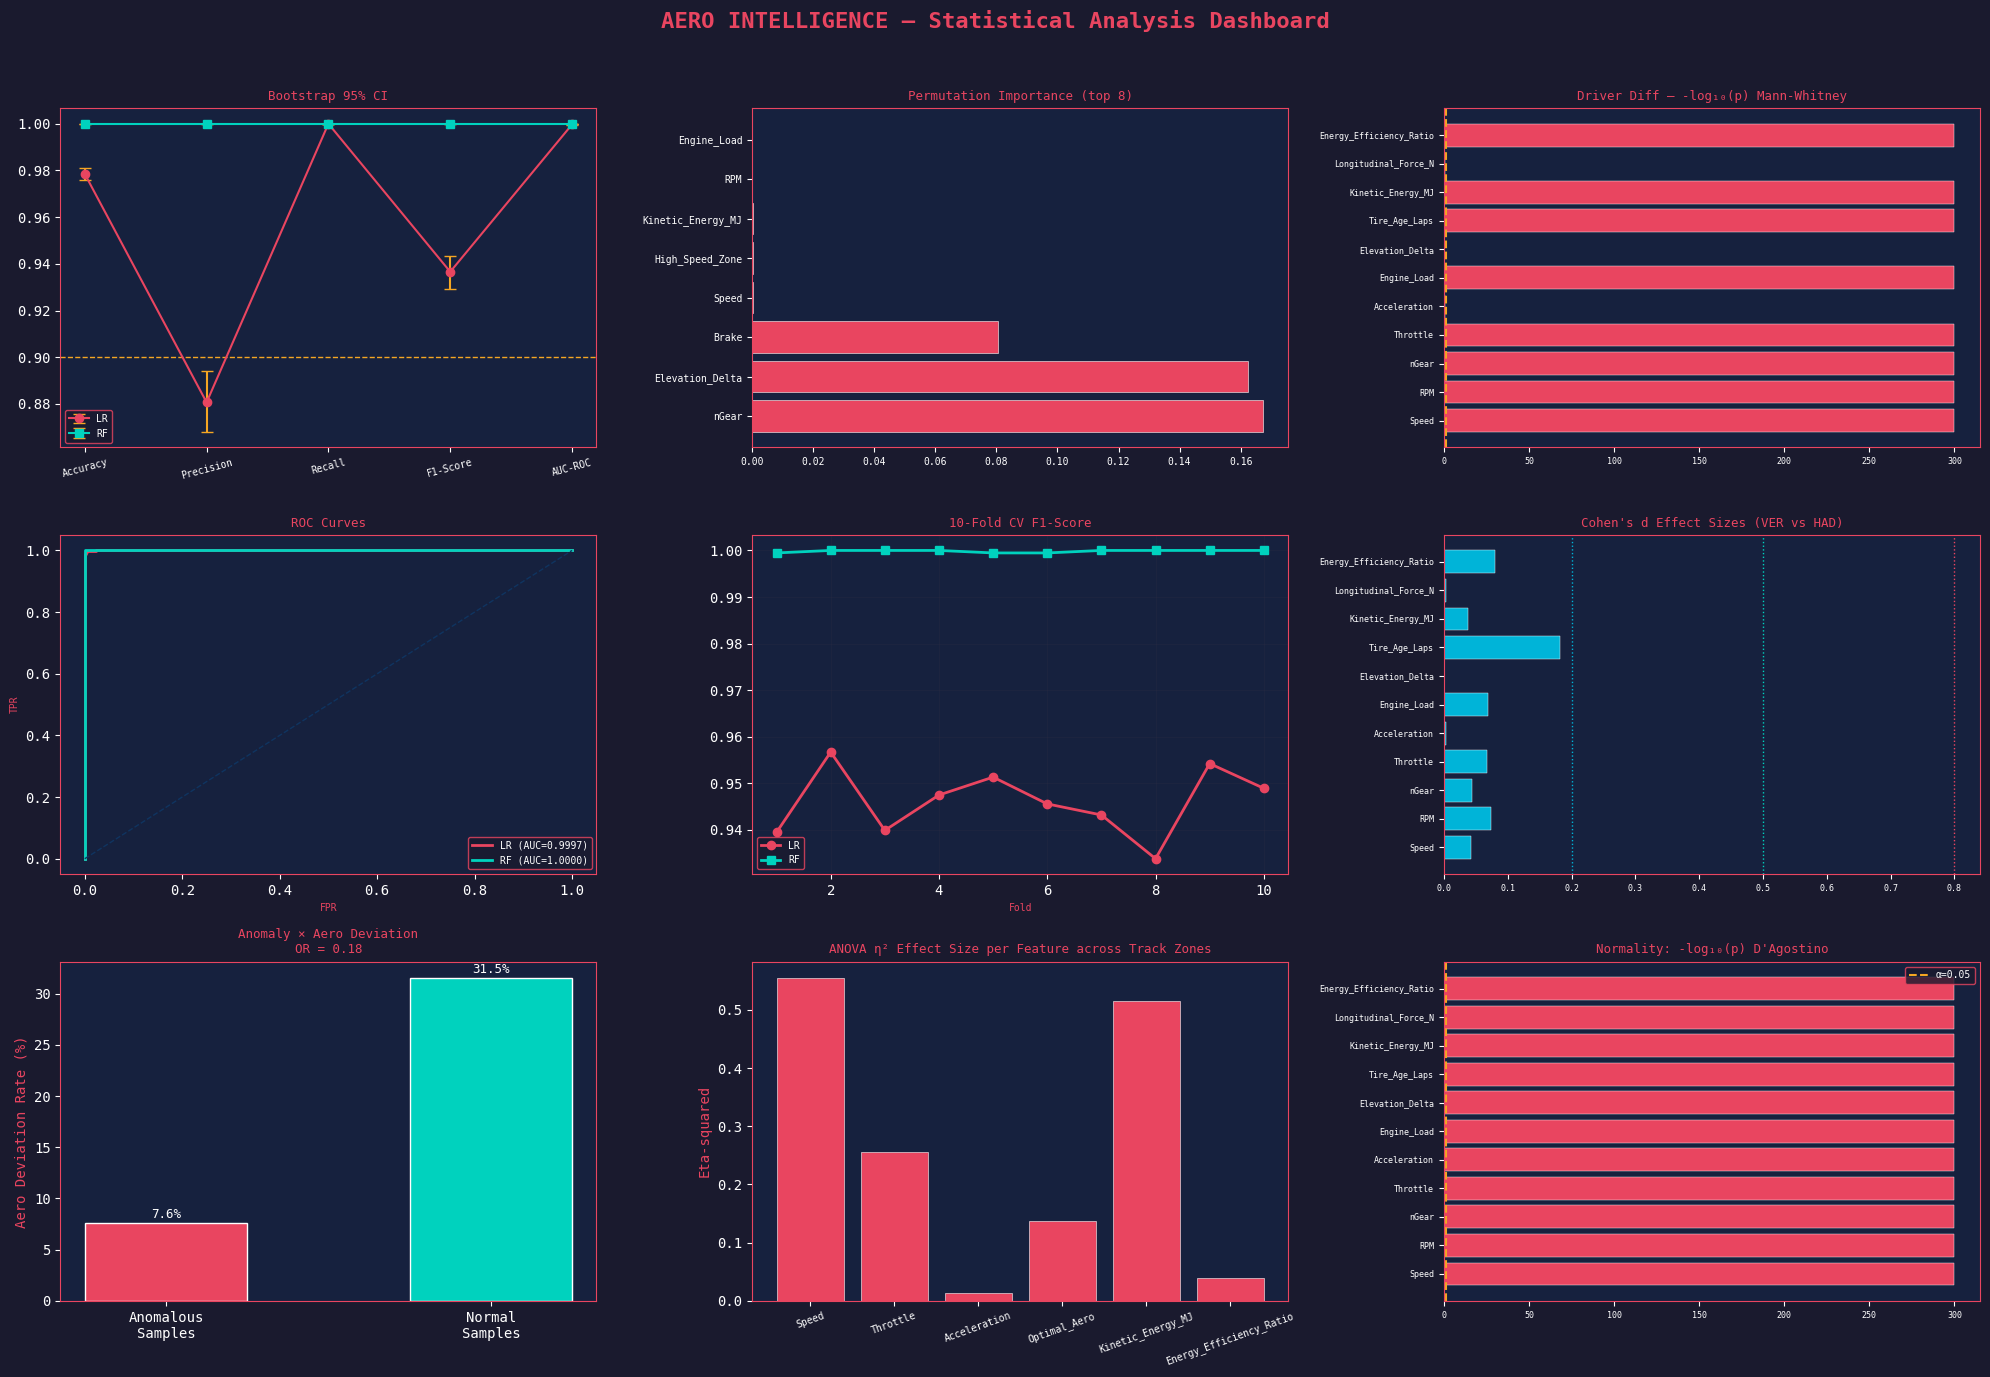

  Master dashboard saved → graphs/stat_09_master_dashboard.png


In [29]:
# ── 10.2  Final comprehensive visualisation dashboard ─────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('AERO INTELLIGENCE — Statistical Analysis Dashboard',
             fontsize=16, color=F1_RED, fontweight='bold', y=0.98)

# ── Panel A: Bootstrap CIs ────────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
sub_lr = boot_df[boot_df['Model'] == 'Logistic Regression']
sub_rf = boot_df[boot_df['Model'] == 'Random Forest']
x_pts  = range(len(sub_lr))
ax1.errorbar(list(x_pts), sub_lr['Point_Est'],
             yerr=[sub_lr['Point_Est']-sub_lr['CI_lo_95'], sub_lr['CI_hi_95']-sub_lr['Point_Est']],
             fmt='o-', color=F1_RED, ecolor=F1_GOLD, capsize=4, label='LR')
ax1.errorbar(list(x_pts), sub_rf['Point_Est'],
             yerr=[sub_rf['Point_Est']-sub_rf['CI_lo_95'], sub_rf['CI_hi_95']-sub_rf['Point_Est']],
             fmt='s-', color=F1_GREEN, ecolor=F1_GOLD, capsize=4, label='RF')
ax1.set_xticks(list(x_pts))
ax1.set_xticklabels(sub_lr['Metric'].tolist(), fontsize=7, rotation=15)
ax1.set_title('Bootstrap 95% CI', fontsize=9)
ax1.legend(fontsize=7)
ax1.axhline(0.9, color=F1_GOLD, lw=1, linestyle='--')

# ── Panel B: Permutation importances ─────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 2)
top8 = perm_df.head(8)
ax2.barh(top8['Feature'].tolist(), top8['Importance'],
         color=[F1_RED if s == 'YES' else F1_TEAL for s in top8['Sig']],
         edgecolor=F1_WHITE, linewidth=0.4)
ax2.set_title('Permutation Importance (top 8)', fontsize=9)
ax2.tick_params(labelsize=7)

# ── Panel C: Driver MW p-values ───────────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
sig_colors = [F1_RED if p < ALPHA else F1_GREEN for p in driver_df['MW_p']]
ax3.barh(driver_df['Feature'].tolist(), -np.log10(driver_df['MW_p'] + 1e-300),
         color=sig_colors, edgecolor=F1_WHITE, linewidth=0.3)
ax3.axvline(-np.log10(ALPHA), color=F1_GOLD, lw=1.5, linestyle='--')
ax3.set_title('Driver Diff — -log₁₀(p) Mann-Whitney', fontsize=9)
ax3.tick_params(labelsize=6)

# ── Panel D: ROC curves ───────────────────────────────────────────────────────
ax4 = fig.add_subplot(3, 3, 4)
for name, prob, color in [('LR', y_prob_lr, F1_RED), ('RF', y_prob_rf, F1_GREEN)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ax4.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc_val:.4f})')
ax4.plot([0,1],[0,1], color=F1_BLUE, lw=1, linestyle='--')
ax4.set_title('ROC Curves', fontsize=9)
ax4.set_xlabel('FPR', fontsize=7)
ax4.set_ylabel('TPR', fontsize=7)
ax4.legend(fontsize=7)

# ── Panel E: CV stability F1 ─────────────────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 5)
ax5.plot(range(1,11), cv_metrics['F1-Score']['LR'], 'o-', color=F1_RED,   lw=2, label='LR')
ax5.plot(range(1,11), cv_metrics['F1-Score']['RF'], 's-', color=F1_GREEN, lw=2, label='RF')
ax5.set_title('10-Fold CV F1-Score', fontsize=9)
ax5.set_xlabel('Fold', fontsize=7)
ax5.legend(fontsize=7)
ax5.grid(alpha=0.3)

# ── Panel F: Effect sizes driver comparison ───────────────────────────────────
ax6 = fig.add_subplot(3, 3, 6)
ax6.barh(driver_df['Feature'].tolist(), driver_df['Cohens_d'].abs(),
         color=effect_colors, edgecolor=F1_WHITE, linewidth=0.3)
ax6.axvline(0.2, color=F1_TEAL,  lw=1, linestyle=':')
ax6.axvline(0.5, color=F1_GREEN, lw=1, linestyle=':')
ax6.axvline(0.8, color=F1_RED,   lw=1, linestyle=':')
ax6.set_title("Cohen's d Effect Sizes (VER vs HAD)", fontsize=9)
ax6.tick_params(labelsize=6)

# ── Panel G: Anomaly Odds Ratio visualisation ─────────────────────────────────
ax7 = fig.add_subplot(3, 3, 7)
labels_or  = ['Anomalous\nSamples', 'Normal\nSamples']
rates_or   = [df[df['Is_Anomaly']==1]['Aero_Deviation'].mean()*100,
              df[df['Is_Anomaly']==0]['Aero_Deviation'].mean()*100]
ax7.bar(labels_or, rates_or, color=[F1_RED, F1_GREEN], edgecolor=F1_WHITE, width=0.5)
for i, v in enumerate(rates_or):
    ax7.text(i, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)
ax7.set_ylabel('Aero Deviation Rate (%)')
ax7.set_title(f'Anomaly × Aero Deviation\nOR = {odds_ratio:.2f}', fontsize=9)

# ── Panel H: Kruskal-Wallis eta-squared ───────────────────────────────────────
ax8 = fig.add_subplot(3, 3, 8)
ax8.bar(zone_df['Feature'].tolist(), zone_df['Eta_sq'],
        color=F1_RED, edgecolor=F1_WHITE, linewidth=0.4)
ax8.set_title('ANOVA η² Effect Size per Feature across Track Zones', fontsize=9)
ax8.tick_params(axis='x', rotation=20, labelsize=7)
ax8.set_ylabel('Eta-squared')

# ── Panel I: Normality test summary ───────────────────────────────────────────
ax9 = fig.add_subplot(3, 3, 9)
norm_colors = [F1_RED if v == 'NON-NORMAL' else F1_GREEN for v in normality_df['Verdict']]
ax9.barh(normality_df['Feature'].tolist(), -np.log10(normality_df['DP_p'] + 1e-300),
         color=norm_colors, edgecolor=F1_WHITE, linewidth=0.3)
ax9.axvline(-np.log10(ALPHA), color=F1_GOLD, lw=1.5, linestyle='--',
            label=f'α={ALPHA}')
ax9.set_title('Normality: -log₁₀(p) D\'Agostino', fontsize=9)
ax9.tick_params(labelsize=6)
ax9.legend(fontsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('graphs/stat_09_master_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Master dashboard saved → graphs/stat_09_master_dashboard.png')

In [30]:
# ── 10.3  Final print — list all saved outputs ────────────────────────────────
print('='*60)
print('  AERO INTELLIGENCE — STATISTICAL ANALYSIS COMPLETE')
print('='*60)
print('\n  CSV outputs saved to stats_outputs/:')
for f in sorted(os.listdir('stats_outputs')):
    print(f'    → {f}')
print('\n  Figures saved to graphs/:')
for f in sorted(f for f in os.listdir('graphs') if f.startswith('stat_')):
    print(f'    → {f}')
print()
print('  Tests completed:')
tests_done = [
    'Shapiro-Wilk Normality Test',
    "D'Agostino-Pearson K² Normality Test",
    'Independent Samples t-test (Welch)',
    'Mann-Whitney U Test (non-parametric)',
    "Levene's Test for Equality of Variances",
    "Cohen's d Effect Size",
    "Cliff's Delta (non-parametric effect size)",
    'Chi-squared Test of Independence',
    "Fisher's Exact Test",
    'Odds Ratio with 95% CI',
    "Cramér's V Effect Size",
    'Pearson Correlation',
    'Spearman Rank Correlation',
    'Point-Biserial Correlation',
    'One-Way ANOVA',
    'Kruskal-Wallis H Test',
    'Dunn Post-Hoc (Bonferroni corrected)',
    'DeLong AUC Significance Test',
    'McNemar Test',
    'Bootstrap 95% CI (n=1000)',
    'Stratified 10-Fold Cross-Validation',
    'Wilcoxon Signed-Rank Test',
    'Permutation Feature Importance (n=30)',
]
for t in tests_done:
    print(f'    ✓ {t}')
print(f'\n  Total: {len(tests_done)} statistical tests applied.')

  AERO INTELLIGENCE — STATISTICAL ANALYSIS COMPLETE

  CSV outputs saved to stats_outputs/:
    → 00_master_summary.csv
    → 01_descriptive_stats.csv
    → 02_driver_descriptive_stats.csv
    → 03_normality_tests.csv
    → 04_driver_comparison_tests.csv
    → 05_feature_target_correlation.csv
    → 06_track_zone_tests.csv
    → 07_posthoc_track_zones.csv
    → 08_anomaly_feature_tests.csv
    → 09_bootstrap_ci.csv
    → 10_permutation_importance.csv

  Figures saved to graphs/:
    → stat_01_distributions.png
    → stat_02_qqplots.png
    → stat_03_driver_comparison.png
    → stat_04_correlations.png
    → stat_05_zone_boxplots.png
    → stat_06_bootstrap_ci.png
    → stat_07_cv_stability.png
    → stat_08_permutation_importance.png
    → stat_09_master_dashboard.png

  Tests completed:
    ✓ Shapiro-Wilk Normality Test
    ✓ D'Agostino-Pearson K² Normality Test
    ✓ Independent Samples t-test (Welch)
    ✓ Mann-Whitney U Test (non-parametric)
    ✓ Levene's Test for Equality of Vari